In [94]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Process all experiments

In [95]:
def compute_global_metrics(entropy, window=10):
    """Compute global metrics for entropy sequence."""
    # Basic statistics
    mean_val = np.mean(entropy)
    median_val = np.median(entropy)
    std_val = np.std(entropy)
    
    # Compute deltas
    deltas = np.diff(entropy)
    abs_deltas = np.abs(deltas)
    
    # Spikes: tokens where both incoming and outgoing deltas are in top 5%
    threshold_95 = np.percentile(abs_deltas, 95)
    num_spikes = 0
    for i in range(1, len(entropy) - 1):
        delta_prev = abs(entropy[i] - entropy[i-1])
        delta_next = abs(entropy[i+1] - entropy[i])
        if delta_prev >= threshold_95 and delta_next >= threshold_95:
            num_spikes += 1
    
    # Phase shifts: detect significant changes in rolling mean/std
    rolling_mean = np.full(len(entropy), np.nan)
    rolling_std = np.full(len(entropy), np.nan)
    for i in range(window, len(entropy)):
        rolling_mean[i] = np.mean(entropy[i-window:i])
        rolling_std[i] = np.std(entropy[i-window:i])
    
    # Detect phase shifts: large changes in rolling statistics
    mean_changes = np.abs(np.diff(rolling_mean[window:]))
    std_changes = np.abs(np.diff(rolling_std[window:]))
    
    mean_change_threshold = np.percentile(mean_changes[~np.isnan(mean_changes)], 90) if len(mean_changes) > 0 else 0
    std_change_threshold = np.percentile(std_changes[~np.isnan(std_changes)], 90) if len(std_changes) > 0 else 0
    
    phase_shifts = 0
    for i in range(len(mean_changes)):
        if (not np.isnan(mean_changes[i]) and mean_changes[i] >= mean_change_threshold) or \
           (not np.isnan(std_changes[i]) and std_changes[i] >= std_change_threshold):
            phase_shifts += 1
    
    return {
        'mean': mean_val,
        'median': median_val,
        'std': std_val,
        'num_spikes': num_spikes,
        'phase_shifts': phase_shifts
    }

In [96]:
# Load all experiments
experiments = {
    'aim_1_20251113_025853': 'experiments/aim_1_20251113_025853/experiment.json',
    'aim_1c_20251113_025929': 'experiments/aim_1c_20251113_025929/experiment.json',
    'aim_2_20251113_130200': 'experiments/aim_2_20251113_130200/experiment.json',
    'aim_2c_20251113_072608': 'experiments/aim_2c_20251113_072608/experiment.json',
    'aim_3_20251113_025935': 'experiments/aim_3_20251113_025935/experiment.json',
    'aim_3c_20251113_081324': 'experiments/aim_3c_20251113_081324/experiment.json',
}

def extract_all_rollouts(experiments):
    """Extract all rollouts with their metrics."""
    all_rollouts = []
    
    for exp_name, exp_path in experiments.items():
        with open(exp_path) as f:
            data = json.load(f)

        condition = 'conditioned' if 'c' in exp_name else 'not_conditioned'
        
        for problem_key, problem_data in data['results'].items():
            problem_idx = problem_data['dataset_index']
            
            for rollout in problem_data['rollouts']:
                # Initialize placeholder for entropy sequence
                entropy_seq = []
                
                # Load the corresponding graph_structure.json
                with open(f'experiments/{exp_name}/problem_{problem_idx}/rollout_{rollout['rollout_idx']}/graph_structure.json', 'r') as f:
                    graph_structure = json.load(f)
                entropy_seq = np.array([item['metric_value'] for item in graph_structure['final_sequence']])
                
                if len(entropy_seq) == 0:
                    continue
                
                # Compute metrics using your existing functions
                global_metrics = compute_global_metrics(np.array(entropy_seq))
                
                all_rollouts.append({
                    'experiment': exp_name,
                    'condition': condition,
                    'problem_idx': problem_idx,
                    'rollout_idx': rollout['rollout_idx'],
                    'is_correct': rollout['is_correct'],
                    'num_tokens': rollout['num_tokens'],
                    'mean_entropy': global_metrics['mean'],
                    'median_entropy': global_metrics['median'],
                    'std_entropy': global_metrics['std'],
                    'num_spikes': global_metrics['num_spikes'],
                    'phase_shifts': global_metrics['phase_shifts'],
                    'max_entropy': np.max(entropy_seq),
                    'late_stage_mean': np.mean(entropy_seq[-int(0.2*len(entropy_seq)):]) if len(entropy_seq) > 5 else np.nan,
                    'cumulative_normalized': np.sum(entropy_seq) / len(entropy_seq)
                })
    
    return pd.DataFrame(all_rollouts)

df = extract_all_rollouts(experiments)

print(f"Total rollouts: {len(df)}")
print(f"Correct: {df['is_correct'].sum()}, Incorrect: {(~df['is_correct']).sum()}")

Total rollouts: 3000
Correct: 1471, Incorrect: 1529


In [97]:
nc_correct = len(df[(df['condition'] == 'not_conditioned') & (df['is_correct'])])
nc_total = len(df[(df['condition'] == 'not_conditioned')])

c_correct = len(df[(df['condition'] == 'conditioned') & (df['is_correct'])])
c_total = len(df[(df['condition'] == 'conditioned')])

display(pd.DataFrame([
    {'Condition': 'Not Conditioned', 'Correct': nc_correct, 'Total': nc_total, 'Accuracy (%)': 100 * nc_correct / nc_total},
    {'Condition': 'Conditioned', 'Correct': c_correct, 'Total': c_total, 'Accuracy (%)': 100 * c_correct / c_total},
]))

,Condition,Correct,Total,Accuracy (%)
0,Not Conditioned,124,1500,8.266667
1,Conditioned,1347,1500,89.800000


In [98]:
display(df.head())
display(df.tail())

,experiment,condition,problem_idx,rollout_idx,is_correct,num_tokens,mean_entropy,median_entropy,std_entropy,num_spikes,phase_shifts,max_entropy,late_stage_mean,cumulative_normalized
0,aim_1_20251113_025853,not_conditioned,0,0,True,1031,0.073540,0.000018,0.226627,20,137,1.859375,0.067520,0.073540
1,aim_1_20251113_025853,not_conditioned,0,1,False,1139,0.098681,0.000126,0.250649,21,154,1.835938,0.098725,0.098681
2,aim_1_20251113_025853,not_conditioned,0,2,False,1220,0.083792,0.000028,0.234245,24,160,2.140625,0.129111,0.083792
3,aim_1_20251113_025853,not_conditioned,0,3,True,1071,0.066520,0.000021,0.202809,22,141,1.445312,0.069744,0.066520
4,aim_1_20251113_025853,not_conditioned,0,4,False,1584,0.095532,0.000062,0.262420,30,215,1.898438,0.160986,0.095532


,experiment,condition,problem_idx,rollout_idx,is_correct,num_tokens,mean_entropy,median_entropy,std_entropy,num_spikes,phase_shifts,max_entropy,late_stage_mean,cumulative_normalized
2995,aim_3c_20251113_081324,conditioned,29,45,True,407,0.498726,0.271484,0.578809,6,66,2.781250,0.356544,0.498726
2996,aim_3c_20251113_081324,conditioned,29,46,True,714,0.378202,0.081299,0.517246,8,106,2.281250,0.279604,0.378202
2997,aim_3c_20251113_081324,conditioned,29,47,True,834,0.225783,0.000814,0.428514,12,122,2.484375,0.394514,0.225783
2998,aim_3c_20251113_081324,conditioned,29,48,True,728,0.388166,0.081787,0.554370,12,104,3.593750,0.171037,0.388166
2999,aim_3c_20251113_081324,conditioned,29,49,True,1051,0.316953,0.037842,0.486683,17,148,3.000000,0.260108,0.316953


# 4-Panel Comparison

In [99]:
def compute_per_step_metrics(entropy, window=10):
    """Compute per-step metrics for entropy sequence."""
    n = len(entropy)
    
    # Cumulative sum
    cumsum = np.cumsum(entropy)
    
    # Rolling volatility (std)
    volatility = np.full(n, np.nan)
    for i in range(window, n):
        volatility[i] = np.std(entropy[i-window:i])
    
    # Rolling slope
    slope = np.full(n, np.nan)
    for i in range(window, n):
        slope[i] = np.polyfit(range(window), entropy[i-window:i], 1)[0]
    
    return {
        'cumsum': cumsum,
        'volatility': volatility,
        'slope': slope
    }

In [104]:
def plot_entropy_4panel(df, exp_names, problem_idx=None, wspace=0.15, hspace=0.15):
    """
    Create 4-panel entropy visualization.
    
    Parameters:
    - df: Full dataframe with all rollouts
    - exp_names: List of experiment names to include
    - problem_idx: Single problem number, or None for all problems
    - wspace, hspace: Spacing between panels
    """
    # Filter rollouts
    if problem_idx is not None:
        filtered_df = df[(df['experiment'].isin(exp_names)) & (df['problem_idx'] == problem_idx)]
    else:
        filtered_df = df[df['experiment'].isin(exp_names)]
    
    # Filter into 4 groups
    groups = {
        'Correct, Conditioned': filtered_df[(filtered_df['condition'] == 'conditioned') & (filtered_df['is_correct'])],
        'Incorrect, Conditioned': filtered_df[(filtered_df['condition'] == 'conditioned') & (~filtered_df['is_correct'])],
        'Correct, Not Conditioned': filtered_df[(filtered_df['condition'] == 'not_conditioned') & (filtered_df['is_correct'])],
        'Incorrect, Not Conditioned': filtered_df[(filtered_df['condition'] == 'not_conditioned') & (~filtered_df['is_correct'])]
    }
    
    # Load entropy sequences for each group
    group_sequences = {}
    for group_name, group_df in groups.items():
        sequences = []
        for _, row in group_df.iterrows():
            exp_name_i = row['experiment']
            problem_idx_i = row['problem_idx']
            rollout_idx_i = row['rollout_idx']
            
            try:
                with open(f'experiments/{exp_name_i}/problem_{problem_idx_i}/rollout_{rollout_idx_i}/graph_structure.json', 'r') as f:
                    graph_structure = json.load(f)
                entropy_seq = np.array([item['metric_value'] for item in graph_structure['final_sequence']])
                if len(entropy_seq) > 0:
                    sequences.append(entropy_seq)
            except FileNotFoundError:
                continue
        
        group_sequences[group_name] = sequences
    
    # Compute mean and std at each token position
    def compute_stats(sequences):
        max_len = max(len(seq) for seq in sequences)
        means = []
        stds = []
        
        for pos in range(max_len):
            values = [seq[pos] for seq in sequences if len(seq) > pos]
            if len(values) > 0:
                means.append(np.mean(values))
                stds.append(np.std(values))
            else:
                means.append(np.nan)
                stds.append(np.nan)
        
        return np.array(means), np.array(stds)
    
    group_stats = {}
    for group_name, sequences in group_sequences.items():
        means, stds = compute_stats(sequences)
        group_stats[group_name] = {'means': means, 'stds': stds}
    
    # Create 4-panel plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True,
                             gridspec_kw={'wspace': wspace, 'hspace': hspace})
    axes = axes.flatten()
    
    group_order = [
        'Correct, Conditioned',
        'Correct, Not Conditioned',
        'Incorrect, Conditioned',
        'Incorrect, Not Conditioned'
    ]
    
    for idx, group_name in enumerate(group_order):
        ax = axes[idx]
        stats = group_stats[group_name]
        means = stats['means']
        stds = stats['stds']
        positions = np.arange(len(means))
        
        # Plot mean line
        ax.plot(positions, means, linewidth=2, label='Mean')
        
        # Plot std band
        ax.fill_between(positions, means - stds, means + stds, alpha=0.3, label='±1 std')
        
        # Add title with count inside panel
        title_text = f"{group_name} (n={len(group_sequences[group_name])})"
        ax.text(0.05, 0.95, title_text, transform=ax.transAxes, 
                fontsize=11, fontweight='bold', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)
        
        # Configure spines and ticks
        if idx == 0:
            ax.spines['top'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(True)
            ax.spines['right'].set_visible(True)
            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('right')
            ax.tick_params(labelbottom=True, labelright=True)
        elif idx == 1:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(True)
            ax.spines['left'].set_visible(False)
            ax.xaxis.set_ticks_position('bottom')
            ax.tick_params(labelbottom=True, labelleft=False, labelright=False, 
                          left=False, right=False)
        elif idx == 2:
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(True)
            ax.yaxis.set_ticks_position('right')
            ax.tick_params(labelbottom=False, labeltop=False, labelright=True, labelleft=False,
                          bottom=False, top=False, left=False)
        else:
            ax.spines['bottom'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.tick_params(labelbottom=False, labeltop=False, labelleft=False, labelright=False, 
                          bottom=False, top=False, left=False, right=False)
    
    # Add axis labels
    fig.text(0.5, 0.08, 'Token Position', ha='center', fontsize=12)
    fig.text(0.08, 0.5, 'Entropy', va='center', rotation='vertical', fontsize=12)
    
    plt.show()

## Single Problem Analysis (Problem 0)

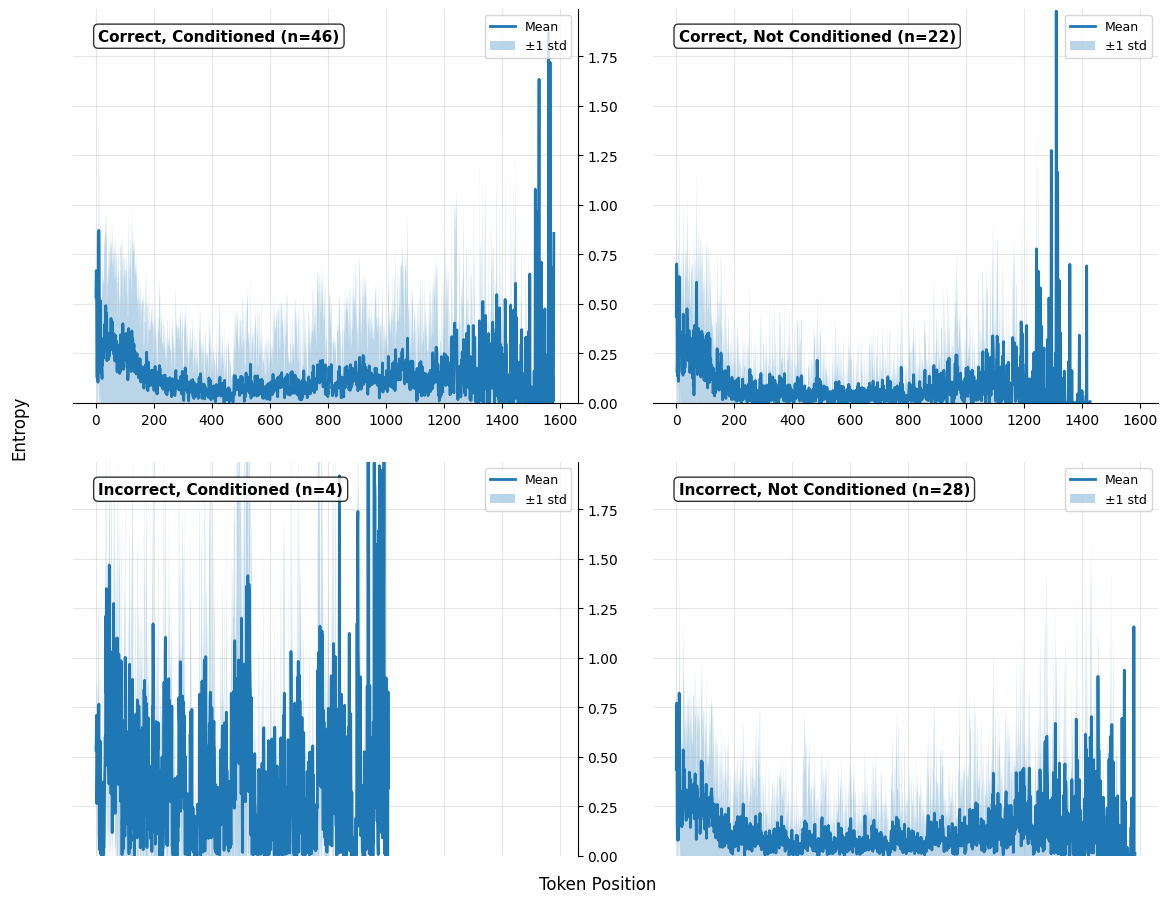

In [105]:
# Analyze single problem (problem 0) from aim_1 and aim_1c
plot_entropy_4panel(
    df=df,
    exp_names=["aim_1_20251113_025853", "aim_1c_20251113_025929"],
    problem_idx=0
)

## Aggregate Analysis (All Rollouts across All Problems Across All Experiments)

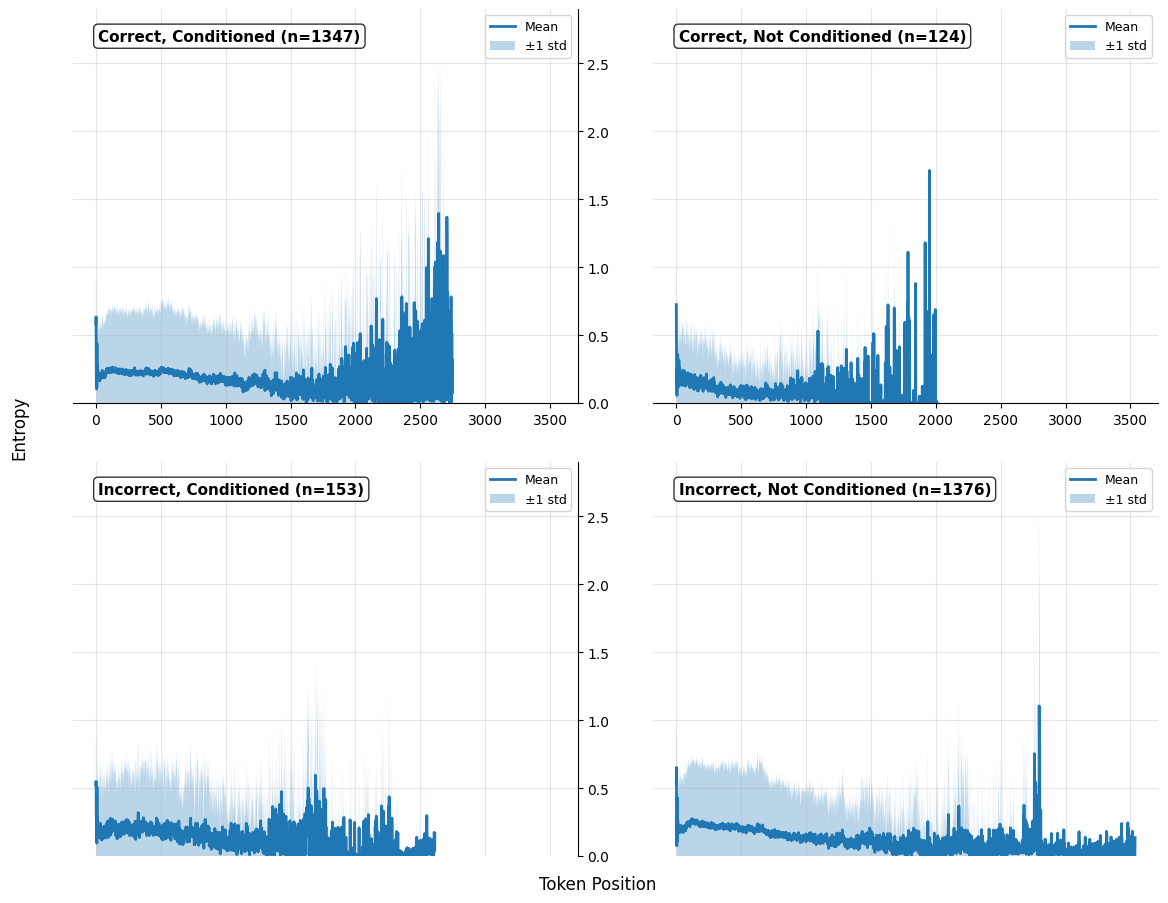

In [106]:
# Analyze across all problems in all experiments
all_experiments = [
    'aim_1_20251113_025853',
    'aim_1c_20251113_025929',
    'aim_2_20251113_130200',
    'aim_2c_20251113_072608',
    'aim_3_20251113_025935',
    'aim_3c_20251113_081324'
]

plot_entropy_4panel(
    df=df,
    exp_names=all_experiments,
    problem_idx=None  # None means all problems
)